# lncRNA Island Validation (hg38 → mm39, primary only)

End-to-end validation of lncRNA structural island predictions:

1. How many reference lncRNAs have at least one structural island?
2. Island counts per gene, island sizes
3. Island alignment results: matched vs unmatched islands, MMD scores
4. Overlap of aligned query islands with mm39 GENCODE annotation
5. Stratification by biotype and MMD score

In [1]:
import json
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyrion.io.bed import read_bed12_file
from pyrion.ops.interval_ops import intersect_intervals

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

PIPELINE_DIR = REPO_ROOT / "hg38_vs_mm39_primary_only"
BED_DIR = PIPELINE_DIR / "intermediate_bed_files"
ANNOTATION_DIR = REPO_ROOT / "input_data" / "mm39_annotation_validation"

UNION_BED = PIPELINE_DIR / "union_transcripts.bed"
UNION_META = PIPELINE_DIR / "union_transcripts_metadata.tsv"
REF_ISLANDS_BED = BED_DIR / "raw_reference_islands.bed"
QUERY_ISLANDS_BED = BED_DIR / "raw_query_islands.bed"
ALIGNED_QUERY_BED = BED_DIR / "aligned_islands_query.bed"
ALIGNED_REF_BED = BED_DIR / "aligned_islands_reference.bed"
ALIGNMENT_TSV = PIPELINE_DIR / "island_alignment_results.tsv"
PREPROCESSED_REF = PIPELINE_DIR / "preprocessed_reference_data.json"

ANNO_BED = ANNOTATION_DIR / "mm39_gencode_all_transcripts.bed"
ANNO_META = ANNOTATION_DIR / "mm39_gencode_metadata.tsv"

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

## 1. Reference lncRNAs and structural islands

How many lncRNA union transcripts exist, and how many have at least one structural island?

In [2]:
# Load union transcript metadata
union_meta = pd.read_csv(UNION_META, sep="\t")
lncrna_ids = set(union_meta[union_meta["biotype"] == "lncRNA"]["transcript_id"])

print(f"Total union transcripts: {len(union_meta):,}")
print(f"  lncRNA: {len(lncrna_ids):,}")

# Parse reference islands BED — extract gene_id from name (U_ENSG...island_N)
ref_islands = read_bed12_file(str(REF_ISLANDS_BED))
ref_island_genes = set()
island_counts = Counter()
island_sizes = []

for t in ref_islands:
    gene_id = t.id.rsplit("_island_", 1)[0]
    ref_island_genes.add(gene_id)
    island_counts[gene_id] += 1
    island_sizes.append(sum(int(e) - int(s) for s, e in t.blocks))

lncrna_with_islands = lncrna_ids & ref_island_genes
lncrna_no_islands = lncrna_ids - ref_island_genes

print(f"\nReference islands: {len(ref_islands):,} islands across {len(ref_island_genes):,} genes")
print(f"lncRNA genes with ≥1 island: {len(lncrna_with_islands):,} / {len(lncrna_ids):,} "
      f"({100 * len(lncrna_with_islands) / len(lncrna_ids):.1f}%)")
print(f"lncRNA genes with NO island: {len(lncrna_no_islands):,} "
      f"({100 * len(lncrna_no_islands) / len(lncrna_ids):.1f}%)")

Total union transcripts: 79,012
  lncRNA: 34,262

Reference islands: 62,420 islands across 21,057 genes
lncRNA genes with ≥1 island: 20,739 / 34,262 (60.5%)
lncRNA genes with NO island: 13,523 (39.5%)


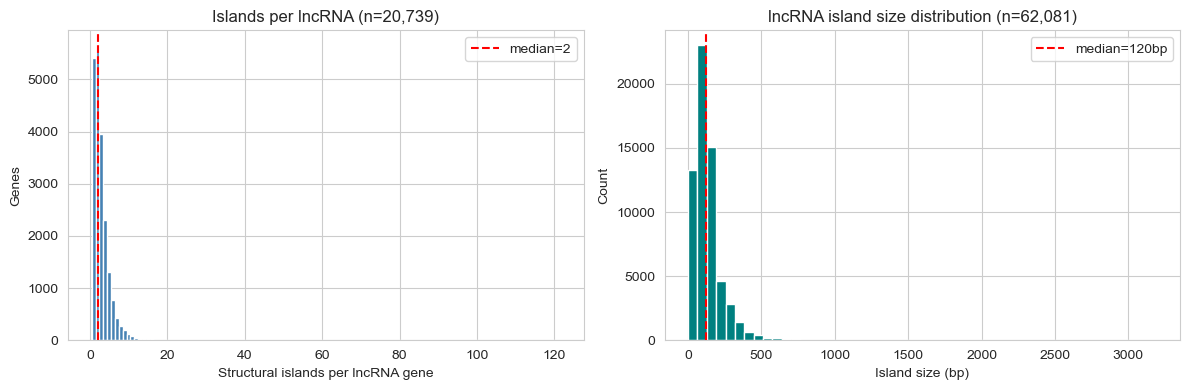

Islands per lncRNA: median=2, mean=3.0, max=121
Island size (bp): median=120, mean=133, max=3192


In [3]:
# Islands per gene and island size distributions
lncrna_island_counts = [island_counts[g] for g in lncrna_with_islands]
lncrna_island_sizes = []
for t in ref_islands:
    gene_id = t.id.rsplit("_island_", 1)[0]
    if gene_id in lncrna_ids:
        lncrna_island_sizes.append(sum(int(e) - int(s) for s, e in t.blocks))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lncrna_island_counts, bins=range(1, max(lncrna_island_counts) + 2),
             color="steelblue", edgecolor="white", align="left")
axes[0].set_xlabel("Structural islands per lncRNA gene")
axes[0].set_ylabel("Genes")
axes[0].set_title(f"Islands per lncRNA (n={len(lncrna_with_islands):,})")
axes[0].axvline(np.median(lncrna_island_counts), color="red", ls="--",
                label=f"median={np.median(lncrna_island_counts):.0f}")
axes[0].legend()

axes[1].hist(lncrna_island_sizes, bins=50, color="teal", edgecolor="white")
axes[1].set_xlabel("Island size (bp)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"lncRNA island size distribution (n={len(lncrna_island_sizes):,})")
axes[1].axvline(np.median(lncrna_island_sizes), color="red", ls="--",
                label=f"median={np.median(lncrna_island_sizes):.0f}bp")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Islands per lncRNA: median={np.median(lncrna_island_counts):.0f}, "
      f"mean={np.mean(lncrna_island_counts):.1f}, max={max(lncrna_island_counts)}")
print(f"Island size (bp): median={np.median(lncrna_island_sizes):.0f}, "
      f"mean={np.mean(lncrna_island_sizes):.0f}, max={max(lncrna_island_sizes)}")

## 2. Island alignment results

How many reference islands found a match in the query? MMD score distribution.

In [4]:
aln = pd.read_csv(ALIGNMENT_TSV, sep="\t")
aln["diag_mmd"] = pd.to_numeric(aln["diag_mmd"], errors="coerce")

# Join biotype
meta_map = dict(zip(union_meta["transcript_id"], union_meta["biotype"]))
aln["biotype"] = aln["gene_id"].map(meta_map)
aln_lncrna = aln[aln["biotype"] == "lncRNA"]

print(f"Total island alignment rows: {len(aln):,}")
print(f"  lncRNA rows: {len(aln_lncrna):,}")
print(f"  unique lncRNA genes with alignments: {aln_lncrna['gene_id'].nunique():,}")
print()
print(f"Alignment types (lncRNA):")
for t, n in aln_lncrna["type"].value_counts().items():
    print(f"  {t}: {n:,}")

Total island alignment rows: 28,780
  lncRNA rows: 28,724
  unique lncRNA genes with alignments: 14,599

Alignment types (lncRNA):
  match: 28,724


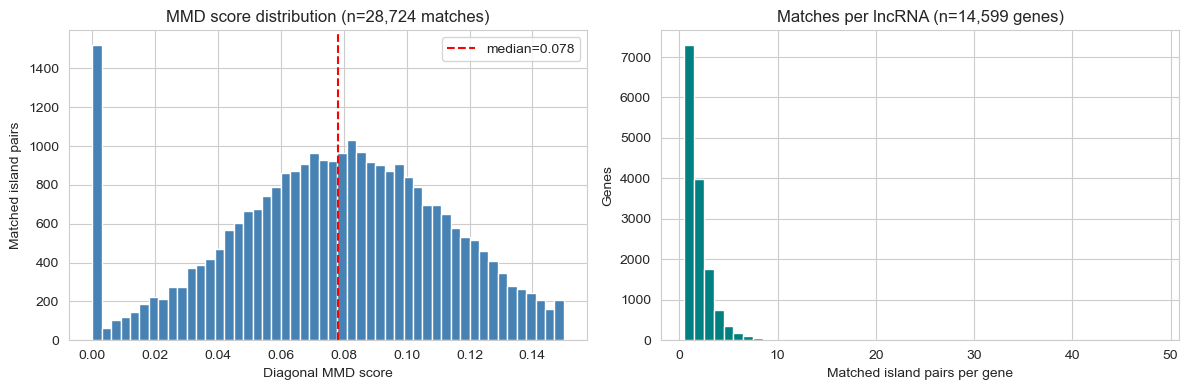


Reference lncRNA islands: 62,081
  with ≥1 match: 25,140 (40.5%)
  unmatched: 36,941


In [5]:
matches = aln_lncrna[aln_lncrna["type"] == "match"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(matches["diag_mmd"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Diagonal MMD score")
axes[0].set_ylabel("Matched island pairs")
axes[0].set_title(f"MMD score distribution (n={len(matches):,} matches)")
med = matches["diag_mmd"].median()
axes[0].axvline(med, color="red", ls="--", label=f"median={med:.3f}")
axes[0].legend()

# Matched islands per gene
matches_per_gene = matches.groupby("gene_id").size()
axes[1].hist(matches_per_gene, bins=range(1, matches_per_gene.max() + 2),
             color="teal", edgecolor="white", align="left")
axes[1].set_xlabel("Matched island pairs per gene")
axes[1].set_ylabel("Genes")
axes[1].set_title(f"Matches per lncRNA (n={len(matches_per_gene):,} genes)")

plt.tight_layout()
plt.show()

# Coverage: what fraction of reference islands got at least one match?
ref_lncrna_islands = set()
for t in ref_islands:
    gene_id = t.id.rsplit("_island_", 1)[0]
    island_idx = t.id.rsplit("_island_", 1)[1]
    if gene_id in lncrna_ids:
        ref_lncrna_islands.add((gene_id, f"R{island_idx}"))

matched_ref_islands = set(zip(matches["gene_id"], matches["ref_island"]))
matched_lncrna = matched_ref_islands & ref_lncrna_islands

print(f"\nReference lncRNA islands: {len(ref_lncrna_islands):,}")
print(f"  with ≥1 match: {len(matched_lncrna):,} ({100 * len(matched_lncrna) / len(ref_lncrna_islands):.1f}%)")
print(f"  unmatched: {len(ref_lncrna_islands) - len(matched_lncrna):,}")

## 3. Aligned query islands vs mm39 annotation

For each aligned query island (predicted structural region in mm39),
compute exon-level overlap with GENCODE mm39 annotation.

In [6]:
annotation = read_bed12_file(str(ANNO_BED))
aligned_query = read_bed12_file(str(ALIGNED_QUERY_BED))

print(f"Aligned query islands: {len(aligned_query):,}")
print(f"mm39 GENCODE transcripts: {len(annotation):,}")

Aligned query islands: 14,654
mm39 GENCODE transcripts: 278,326


In [7]:
# Build gene_id -> biotype map for the predictions
pred_biotype = {}
for t in aligned_query:
    gene_id = t.id.replace("_aligned", "")
    pred_biotype[t.id] = meta_map.get(gene_id, "unknown")

# Also load island alignment MMD scores per gene (use median diag_mmd)
gene_mmd = matches.groupby("gene_id")["diag_mmd"].median().to_dict()

rows = []
for pred in aligned_query:
    pred_blocks = pred.blocks
    pred_bp = int(np.sum(pred_blocks[:, 1] - pred_blocks[:, 0]))

    hits = annotation.get_transcripts_in_interval(pred)
    best_bp, best_tid = 0, None
    for t in hits:
        isect = intersect_intervals(pred_blocks, t.blocks)
        if len(isect) > 0:
            bp = int(np.sum(isect[:, 1] - isect[:, 0]))
            if bp > best_bp:
                best_bp, best_tid = bp, t.id

    gene_id = pred.id.replace("_aligned", "")
    rows.append({
        "pred_id": pred.id,
        "gene_id": gene_id,
        "chrom": pred.chrom,
        "start": pred.start,
        "end": pred.end,
        "n_exons": len(pred_blocks),
        "pred_bp": pred_bp,
        "biotype": pred_biotype.get(pred.id, "unknown"),
        "median_mmd": gene_mmd.get(gene_id, np.nan),
        "overlap_bp": best_bp,
        "overlap_pct": best_bp / pred_bp * 100 if pred_bp > 0 else 0,
        "best_match": best_tid,
    })

ov = pd.DataFrame(rows)
ov["has_overlap"] = ov["overlap_bp"] > 0
ov["over50"] = ov["overlap_pct"] >= 50

print(f"Computed overlaps for {len(ov):,} aligned islands")

Computed overlaps for 14,654 aligned islands


In [8]:
# Overall overlap summary
n = len(ov)
n_any = ov["has_overlap"].sum()
n_50 = ov["over50"].sum()
n_full = (ov["overlap_pct"] >= 99).sum()

print(f"=== Aligned Island Overlap Summary ===")
print(f"Total aligned islands:    {n:,}")
print(f"Any exon overlap:         {n_any:,}  ({100*n_any/n:.1f}%)")
print(f"≥50% overlap:             {n_50:,}  ({100*n_50/n:.1f}%)")
print(f"≥99% overlap (full):      {n_full:,}  ({100*n_full/n:.1f}%)")
print(f"No overlap:               {n - n_any:,}  ({100*(n - n_any)/n:.1f}%)")

hits = ov[ov["has_overlap"]]
if len(hits) > 0:
    print(f"\nAmong {n_any:,} with overlap:")
    print(f"  median overlap: {hits['overlap_pct'].median():.1f}%")
    print(f"  mean overlap:   {hits['overlap_pct'].mean():.1f}%")

# Per-gene summary
gene_ov = ov.groupby("gene_id").agg(
    n_islands=("pred_id", "count"),
    any_overlap=("has_overlap", "any"),
    all_overlap=("has_overlap", "all"),
    mean_pct=("overlap_pct", "mean"),
)
n_genes = len(gene_ov)
n_genes_any = gene_ov["any_overlap"].sum()
n_genes_all = gene_ov["all_overlap"].sum()

print(f"\n=== Per-gene summary ===")
print(f"Genes with aligned islands:        {n_genes:,}")
print(f"  ≥1 island overlapping annotation: {n_genes_any:,} ({100*n_genes_any/n_genes:.1f}%)")
print(f"  ALL islands overlapping:          {n_genes_all:,} ({100*n_genes_all/n_genes:.1f}%)")

=== Aligned Island Overlap Summary ===
Total aligned islands:    14,654
Any exon overlap:         4,971  (33.9%)
≥50% overlap:             2,954  (20.2%)
≥99% overlap (full):      1,606  (11.0%)
No overlap:               9,683  (66.1%)

Among 4,971 with overlap:
  median overlap: 57.1%
  mean overlap:   61.8%

=== Per-gene summary ===
Genes with aligned islands:        14,654
  ≥1 island overlapping annotation: 4,971 (33.9%)
  ALL islands overlapping:          4,971 (33.9%)


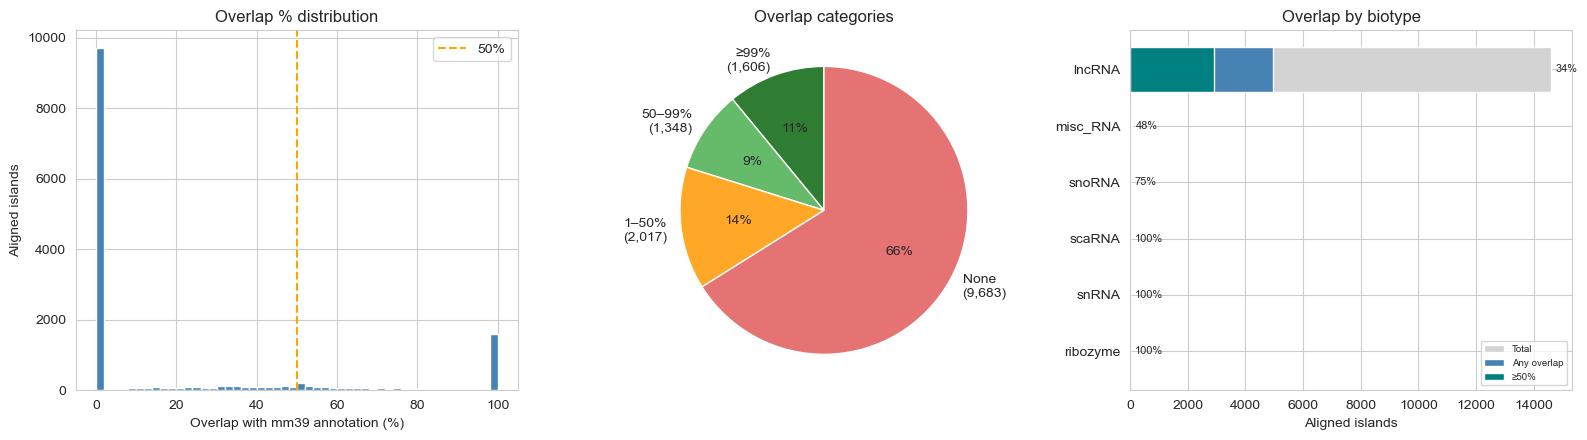

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Overlap % histogram
axes[0].hist(ov["overlap_pct"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Overlap with mm39 annotation (%)")
axes[0].set_ylabel("Aligned islands")
axes[0].set_title("Overlap % distribution")
axes[0].axvline(50, color="orange", ls="--", label="50%")
axes[0].legend()

# 2. Overlap categories pie
cats = [
    ("≥99%", (ov["overlap_pct"] >= 99).sum()),
    ("50–99%", ((ov["overlap_pct"] >= 50) & (ov["overlap_pct"] < 99)).sum()),
    ("1–50%", ((ov["overlap_pct"] > 0) & (ov["overlap_pct"] < 50)).sum()),
    ("None", (ov["overlap_pct"] == 0).sum()),
]
labels, values = zip(*cats)
colors = ["#2e7d32", "#66bb6a", "#ffa726", "#e57373"]
axes[1].pie(values, labels=[f"{l}\n({v:,})" for l, v in cats],
            colors=colors, autopct="%1.0f%%", startangle=90)
axes[1].set_title("Overlap categories")

# 3. Overlap by biotype
ov_lncrna = ov[ov["biotype"] == "lncRNA"]
bt_groups = ov.groupby("biotype").agg(
    total=("pred_id", "count"),
    with_overlap=("has_overlap", "sum"),
    over50=("over50", "sum"),
).sort_values("total", ascending=True)
top_bts = bt_groups.tail(8)

y = np.arange(len(top_bts))
axes[2].barh(y, top_bts["total"], color="lightgrey", edgecolor="white", label="Total")
axes[2].barh(y, top_bts["with_overlap"], color="steelblue", edgecolor="white", label="Any overlap")
axes[2].barh(y, top_bts["over50"], color="teal", edgecolor="white", label="≥50%")
axes[2].set_yticks(y)
axes[2].set_yticklabels(top_bts.index)
axes[2].set_xlabel("Aligned islands")
axes[2].set_title("Overlap by biotype")
axes[2].legend(loc="lower right", fontsize=7)
for i, (tot, hit) in enumerate(zip(top_bts["total"], top_bts["with_overlap"])):
    if tot > 0:
        axes[2].text(tot + max(top_bts["total"]) * 0.01, i,
                     f"{100*hit/tot:.0f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 4. Overlap vs MMD score

Do islands with lower MMD (= more similar embeddings) overlap annotation more often?

=== Overlap by MMD score ===
         total  any_overlap  over_50  median_pct  hit_rate  over50_rate
mmd_bin                                                                
<0.1     11184         3949     2282         0.0      35.3         20.4
0.1–0.2   3415          992      643         0.0      29.0         18.8
0.2–0.3      0            0        0         NaN       NaN          NaN
0.3–0.5      0            0        0         NaN       NaN          NaN
≥0.5         0            0        0         NaN       NaN          NaN


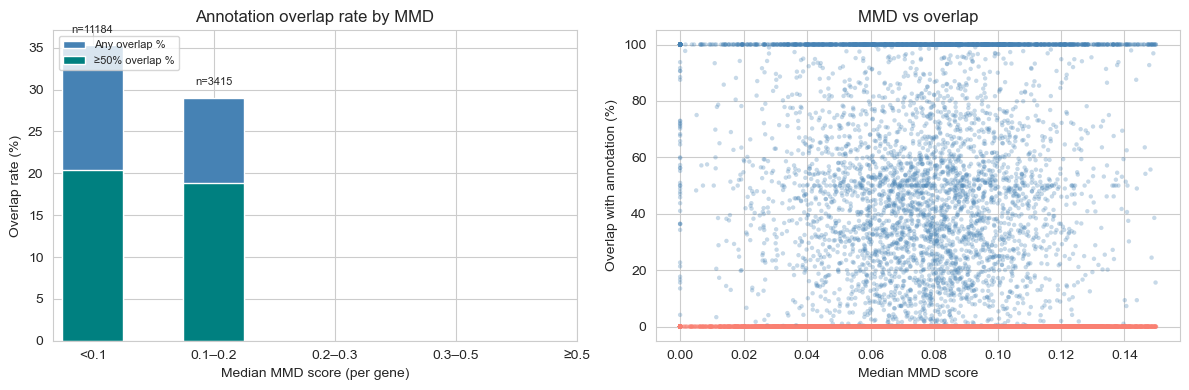

In [10]:
mmd_bins = [0, 0.1, 0.2, 0.3, 0.5, 1.01]
mmd_labels = ["<0.1", "0.1–0.2", "0.2–0.3", "0.3–0.5", "≥0.5"]
ov["mmd_bin"] = pd.cut(ov["median_mmd"], bins=mmd_bins, labels=mmd_labels, right=False)

mmd_stats = ov.groupby("mmd_bin", observed=False).agg(
    total=("pred_id", "count"),
    any_overlap=("has_overlap", "sum"),
    over_50=("over50", "sum"),
    median_pct=("overlap_pct", "median"),
)
mmd_stats["hit_rate"] = (100 * mmd_stats["any_overlap"] / mmd_stats["total"]).round(1)
mmd_stats["over50_rate"] = (100 * mmd_stats["over_50"] / mmd_stats["total"]).round(1)

print("=== Overlap by MMD score ===")
print(mmd_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(mmd_labels))
axes[0].bar(x, mmd_stats["hit_rate"], color="steelblue", edgecolor="white", width=0.5,
            label="Any overlap %")
axes[0].bar(x, mmd_stats["over50_rate"], color="teal", edgecolor="white", width=0.5,
            label="≥50% overlap %")
axes[0].set_xticks(x)
axes[0].set_xticklabels(mmd_labels)
axes[0].set_xlabel("Median MMD score (per gene)")
axes[0].set_ylabel("Overlap rate (%)")
axes[0].set_title("Annotation overlap rate by MMD")
axes[0].legend(fontsize=8)
for i, tot in enumerate(mmd_stats["total"]):
    axes[0].text(i, max(mmd_stats["hit_rate"].iloc[i], mmd_stats["over50_rate"].iloc[i]) + 1.5,
                 f"n={tot}", ha="center", fontsize=8)

# Scatter: MMD vs overlap %
sub = ov.dropna(subset=["median_mmd"])
axes[1].scatter(sub["median_mmd"], sub["overlap_pct"], alpha=0.3, s=10,
                c=sub["has_overlap"].map({True: "steelblue", False: "salmon"}),
                edgecolors="none")
axes[1].set_xlabel("Median MMD score")
axes[1].set_ylabel("Overlap with annotation (%)")
axes[1].set_title("MMD vs overlap")

plt.tight_layout()
plt.show()

## 5. Prediction precision: inside vs outside annotation

For aligned islands that DO overlap annotation, how much of the predicted region
falls inside vs outside annotated exons?

=== Prediction precision (islands with overlap) ===
Total islands with overlap: 4,971
  median overlap:  57.1%
  median outside:  42.9%
  mean overlap:    61.8%
  mean outside:    38.2%


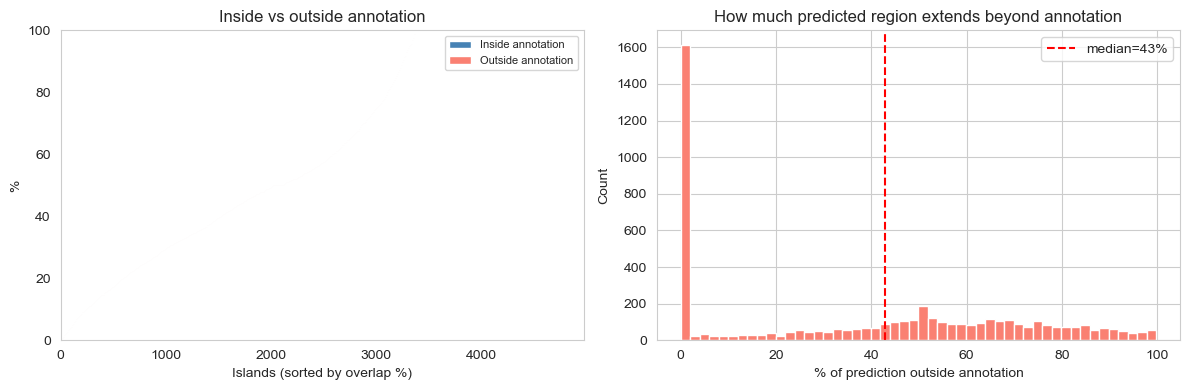

In [11]:
hits_df = ov[ov["has_overlap"]].copy()
hits_df["outside_bp"] = hits_df["pred_bp"] - hits_df["overlap_bp"]
hits_df["outside_pct"] = 100 - hits_df["overlap_pct"]

print(f"=== Prediction precision (islands with overlap) ===")
print(f"Total islands with overlap: {len(hits_df):,}")
print(f"  median overlap:  {hits_df['overlap_pct'].median():.1f}%")
print(f"  median outside:  {hits_df['outside_pct'].median():.1f}%")
print(f"  mean overlap:    {hits_df['overlap_pct'].mean():.1f}%")
print(f"  mean outside:    {hits_df['outside_pct'].mean():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Stacked: inside vs outside annotation per island (sorted by overlap %)
sorted_hits = hits_df.sort_values("overlap_pct", ascending=True).reset_index(drop=True)
axes[0].bar(range(len(sorted_hits)), sorted_hits["overlap_pct"],
            color="steelblue", label="Inside annotation", width=1.0)
axes[0].bar(range(len(sorted_hits)), sorted_hits["outside_pct"],
            bottom=sorted_hits["overlap_pct"],
            color="salmon", label="Outside annotation", width=1.0)
axes[0].set_xlabel("Islands (sorted by overlap %)")
axes[0].set_ylabel("%")
axes[0].set_title("Inside vs outside annotation")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, len(sorted_hits))

# Histogram of outside %
axes[1].hist(hits_df["outside_pct"], bins=50, color="salmon", edgecolor="white")
axes[1].set_xlabel("% of prediction outside annotation")
axes[1].set_ylabel("Count")
axes[1].set_title("How much predicted region extends beyond annotation")
axes[1].axvline(hits_df["outside_pct"].median(), color="red", ls="--",
                label=f"median={hits_df['outside_pct'].median():.0f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Full funnel: reference lncRNAs → islands → matches → annotation overlap

In [12]:
# Genes that have at least one aligned island overlapping annotation
genes_with_anno_hit = ov[ov["has_overlap"]]["gene_id"].nunique()
genes_with_50_hit = ov[ov["over50"]]["gene_id"].nunique()

funnel = [
    ("lncRNA union transcripts", len(lncrna_ids)),
    ("with ≥1 structural island", len(lncrna_with_islands)),
    ("with ≥1 aligned island (query match)", aln_lncrna["gene_id"].nunique()),
    ("with ≥1 island overlapping mm39 annotation", genes_with_anno_hit),
    ("with ≥1 island ≥50% overlap", genes_with_50_hit),
]

print(f"{'Stage':<55} {'Count':>7}  {'% of lncRNAs':>12}")
print("-" * 78)
for label, count in funnel:
    pct = 100 * count / funnel[0][1] if funnel[0][1] else 0
    print(f"{label:<55} {count:>7,}  {pct:>11.1f}%")

print("\nStep-wise losses:")
for i in range(1, len(funnel)):
    prev_label, prev_n = funnel[i - 1]
    curr_label, curr_n = funnel[i]
    lost = prev_n - curr_n
    if prev_n > 0:
        print(f"  {prev_label}")
        print(f"    → {curr_label}: "
              f"{'+' if lost < 0 else '-'}{abs(lost):,} ({100 * lost / prev_n:+.1f}%)")

Stage                                                     Count  % of lncRNAs
------------------------------------------------------------------------------
lncRNA union transcripts                                 34,262        100.0%
with ≥1 structural island                                20,739         60.5%
with ≥1 aligned island (query match)                     14,599         42.6%
with ≥1 island overlapping mm39 annotation                4,971         14.5%
with ≥1 island ≥50% overlap                               2,954          8.6%

Step-wise losses:
  lncRNA union transcripts
    → with ≥1 structural island: -13,523 (+39.5%)
  with ≥1 structural island
    → with ≥1 aligned island (query match): -6,140 (+29.6%)
  with ≥1 aligned island (query match)
    → with ≥1 island overlapping mm39 annotation: -9,628 (+65.9%)
  with ≥1 island overlapping mm39 annotation
    → with ≥1 island ≥50% overlap: -2,017 (+40.6%)
